<a href="https://colab.research.google.com/github/ldfha/RotemAI/blob/main/projects/pro13cnn/cnn1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!cat /etc/os-release
print()
!ls -a      # 현재 디렉토리
!df -h      # 디스크 사용량
!free -h    # 메모리 사용량
!nvidia-smi # GPU 정보
# nvidia-smi: command not found
# 런타임 -> GPU 설정 NVIDIA-SMI 580.82.07 Driver Version: 580.82.07 CUDA Version: 13.0

PRETTY_NAME="Ubuntu 22.04.5 LTS"
NAME="Ubuntu"
VERSION_ID="22.04"
VERSION="22.04.5 LTS (Jammy Jellyfish)"
VERSION_CODENAME=jammy
ID=ubuntu
ID_LIKE=debian
HOME_URL="https://www.ubuntu.com/"
SUPPORT_URL="https://help.ubuntu.com/"
BUG_REPORT_URL="https://bugs.launchpad.net/ubuntu/"
PRIVACY_POLICY_URL="https://www.ubuntu.com/legal/terms-and-policies/privacy-policy"
UBUNTU_CODENAME=jammy

.  ..  .config	sample_data
Filesystem      Size  Used Avail Use% Mounted on
overlay         113G   43G   70G  39% /
tmpfs            64M     0   64M   0% /dev
shm             5.7G     0  5.7G   0% /dev/shm
/dev/root       2.0G  1.3G  696M  65% /usr/sbin/docker-init
/dev/sda1       119G   48G   72G  41% /opt/bin/.nvidia
tmpfs           6.4G   32K  6.4G   1% /var/colab
tmpfs           6.4G     0  6.4G   0% /proc/acpi
tmpfs           6.4G     0  6.4G   0% /proc/scsi
tmpfs           6.4G     0  6.4G   0% /sys/firmware
               total        used        free      shared  buff/cache   available
Mem:        

In [ ]:
# MNIST dataset으로 CNN 실습
import tensorflow as tf
print(tf.__version__)
import numpy as np
import matplotlib.pyplot as plt

# 1) 데이터 준비
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
print(x_train[0])
print(x_train.shape)    # (60000, 28, 28)

# 채널(channel) 추가 (흑백인 경우 1)
x_train = x_train.reshape((-1, 28, 28, 1)).astype('float') / 255.0  # 정규화
x_test = x_test.reshape((-1, 28, 28, 1)).astype('float') / 255.0  # 정규화
print(x_train.shape)    # (60000, 28, 28, 1)

2.20.0
[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3  18  18  18 126 136
  175  26 166 255 247 127   0   0   0   0]
 [  0   0   0   0   0   0   0   0  30  36  94 154 170 253 253 253 253 253
  225 172 253 242 195  64   0   0   0   0]
 [  0   0   0   0   0   0   0  49 238 253 253 253 253 253 253 253 253 251
   93  82  82  56  39   0   0   0   0   0]
 [  0   0   0   0   0   0   0  18 219 253 253 253 253 253

In [ ]:
# 2) 모델 정의

model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(28, 28, 1)),   # 인덱스 제외, 이미지의 높이, 너비, 채널

    # Convolution - Conv1D : text, Conv2D : 이미지, Conv3D : 영상, ConvLSTM : 자연어
    tf.keras.layers.Conv2D(filters=16, kernel_size=(3, 3), padding='same', activation='relu'),
    # (2, 2) 필터 내에서 가장 큰 값만 추출하여서 입력 크기를 줄임
    tf.keras.layers.MaxPool2D(pool_size=(2, 2)),  # pool_size=2
    # 과적합 방지 (optional)
    tf.keras.layers.Dropout(rate=0.2),

    tf.keras.layers.Conv2D(filters=32, kernel_size=(3, 3), padding='same', activation='relu'),
    tf.keras.layers.MaxPool2D(pool_size=(2, 2)),
    tf.keras.layers.Dropout(rate=0.2),

    tf.keras.layers.Flatten(),  # FCLayer (Fully Connected Layer) 1차원으로 구조 변경

    tf.keras.layers.Dense(units=64, activation='relu'),
    tf.keras.layers.Dropout(rate=0.3),
    tf.keras.layers.Dense(units=32, activation='relu'),
    tf.keras.layers.Dropout(rate=0.2),
    tf.keras.layers.Dense(units=10, activation='softmax')
])

print(model.summary())

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 28, 28, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 14, 14, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1568)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 64)             │       100,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 107,626 (420.41 KB)

 Trainable params: 107,626 (420.41 KB)

 Non-trainable params: 0 (0.00 B)

None


In [ ]:
# 3) 모델 컴파일
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

es = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = model.fit(
    x_train, y_train, epochs=100, batch_size=128, validation_split=0.1, callbacks=[es], verbose=1
)

Epoch 1/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 13s 18ms/step - accuracy: 0.7897 - loss: 0.6498 - val_accuracy: 0.9740 - val_loss: 0.0962
Epoch 2/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9401 - loss: 0.2143 - val_accuracy: 0.9830 - val_loss: 0.0655
Epoch 3/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9564 - loss: 0.1566 - val_accuracy: 0.9862 - val_loss: 0.0493
Epoch 4/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9648 - loss: 0.1253 - val_accuracy: 0.9857 - val_loss: 0.0488
Epoch 5/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9697 - loss: 0.1121 - val_accuracy: 0.9873 - val_loss: 0.0404
Epoch 6/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9729 - loss: 0.0988 - val_accuracy: 0.9887 - val_loss: 0.0372
Epoch 7/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9753 - loss: 0.0919 - val_accuracy: 0.9890 - val_loss: 0.0402
Epoch 8/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9773 - loss: 0.0810 - val_a

In [ ]:
# 모델 평가 : 아래 둘의 평가 점수의 차이가 크면 과적합 의심
train_loss, train_acc = model.evaluate(x_train, y_train, verbose=0)
print(f'train_loss {train_loss:.4f}, train_acc {train_acc:.4f}')
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f'test_loss {test_loss:.4f}, test_acc {test_acc:.4f}')


train_loss 0.0186, train_acc 0.9946
test_loss 0.0295, test_acc 0.9904


In [ ]:
# 모델 저장 및 재로딩
SAVE_PATH = 'cnn1model.keras'
model.save(SAVE_PATH)
print(f'모델 저장 {SAVE_PATH}')

모델 저장 cnn1model.keras


In [ ]:
loaded_model = tf.keras.models.load_model(SAVE_PATH)
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f'[Reloaded] test loss {test_loss:.4f}, test acc {test_acc:.4f}')

[Reloaded] test loss 0.0295, test acc 0.9904


In [ ]:
# 분류 예측 (편의상 기존 자료 사용)
idx = 0
x_one = x_test[idx:idx + 1]
y_true = int(y_test[idx])
# print(x_one)
print(y_true)   # 7
probs = loaded_model.predict(x_one, verbose=0)[0]
print('probs :', probs)
y_pred = int(np.argmax(probs))
print(f'실제값:{y_true}, 예측값:{y_pred}')   # 실제값:7, 예측값:7

7
probs : [4.1656420e-10 3.7072907e-09 1.1754384e-08 2.7771227e-07 1.2159854e-10
 4.8740244e-13 1.5725598e-15 9.9999940e-01 1.1318509e-09 3.6706507e-07]
실제값:7, 예측값:7


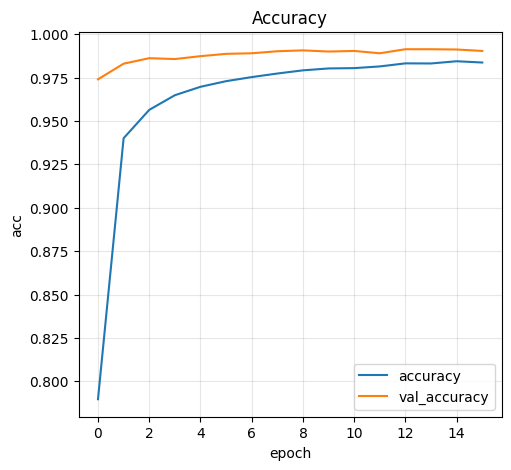

In [ ]:
# 시각화
# 학습 곡선 (정확도/손실)
# %matplotlib inline    # %매직명령어 중 matplotlib의 show() 처리

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.title('Accuracy')
plt.xlabel('epoch')
plt.ylabel('acc')
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

[[ 976    0    1    0    0    0    1    1    1    0]
 [   0 1129    2    0    0    1    1    1    1    0]
 [   3    3 1020    0    1    0    0    3    2    0]
 [   0    0    0 1001    0    6    0    0    3    0]
 [   0    0    0    0  973    0    3    0    2    4]
 [   2    0    0    3    0  886    1    0    0    0]
 [   4    2    0    0    1    4  947    0    0    0]
 [   0    1    7    1    0    0    0 1018    1    0]
 [   3    0    1    2    0    1    0    1  964    2]
 [   1    0    0    0    4    7    0    4    3  990]]


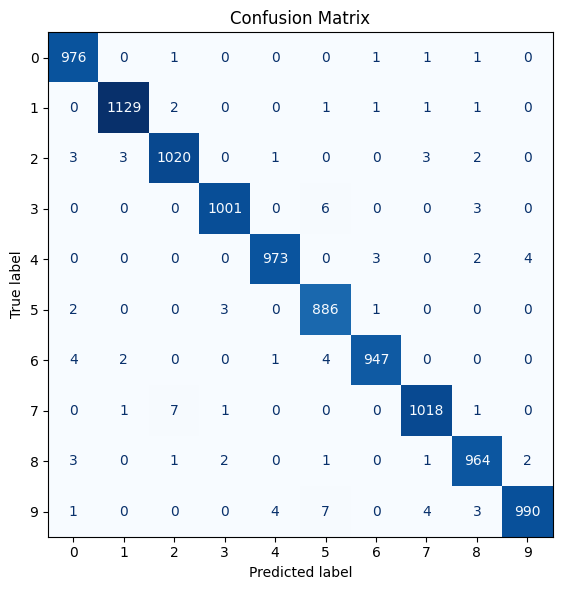

In [ ]:
from IPython.core.pylabtools import figsize
# 혼동행렬로 출력
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
y_pred_all = np.argmax(loaded_model.predict(x_test, verbose=0), axis=1)
cm = confusion_matrix(y_test, y_pred_all, labels=list(range(10)))
print(cm)
classes = [str(i) for i in range(10)]
disp = ConfusionMatrixDisplay(cm, display_labels=classes)
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap='Blues', values_format='d', colorbar=False)
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()